In [2]:
import numpy as np
import rasterio as rio
import sys
sys.path.append('..')
from utils import d_sl, years, dense_vegetation, sl_tropics, interpolated_modis_folder, modis_files
from delta_temp.tcrit import TCRIT, Tcrit_map, data_both_biomes
from tqdm import tqdm 
from os.path import join, basename
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data_group = []
for year in ['2001', '2020']:
    data = []
    for ext in d_sl.keys():
        values = np.load(f"/data/gaston/ecostress/ecostress/worldwide/deltaTcrit_Tmodis{ext}_{year}_tcrit1981_2010.npy")
        values = values.flatten()
        values = values[~np.isnan(values)]
        low_percentile = 0
        high_percentile = 100

        # Compute percentiles
        low_value = np.percentile(values, low_percentile)
        high_value = np.percentile(values, high_percentile)

        # Filter values within the percentile range
        values = values[(values >= low_value) & (values <= high_value)]
        data.append(values)
    data_group.append(data)
    


In [31]:
for ssp in ['2041_2070_ssp370', '2071_2100_ssp370']:
    data = []
    for ext, sl in d_sl.items():
        y = '2050' if ssp == '2041_2070_ssp370' else '2100'
        filename_delta = f"/data/gaston/ecostress/ecostress/2050-2100_temperatures/delta_tsurf_2020_{y}.tif"
        delta_tsurf = rio.open(filename_delta, 'r').read(1)[sl]
        delta_tsurf[delta_tsurf==-20] = np.nan
        delta_tsurf *= dense_vegetation[sl]
        delta_tsurf[dense_vegetation[sl]==0] = np.nan
        delta_tsurf[~data_both_biomes[sl]] = np.nan


        values = np.load(f"/data/gaston/ecostress/ecostress/worldwide/deltaTcrit_Tmodis{ext}_2020_tcrit{ssp}.npy")
        values = values - delta_tsurf
        values = values.flatten()
        values = values[~np.isnan(values)]
        low_percentile = 0
        high_percentile = 100

        # Compute percentiles
        low_value = np.percentile(values, low_percentile)
        high_value = np.percentile(values, high_percentile)

        # Filter values within the percentile range
        values = values[(values >= low_value) & (values <= high_value)]
        data.append(values)
    data_group.append(data)



<Figure size 640x480 with 0 Axes>

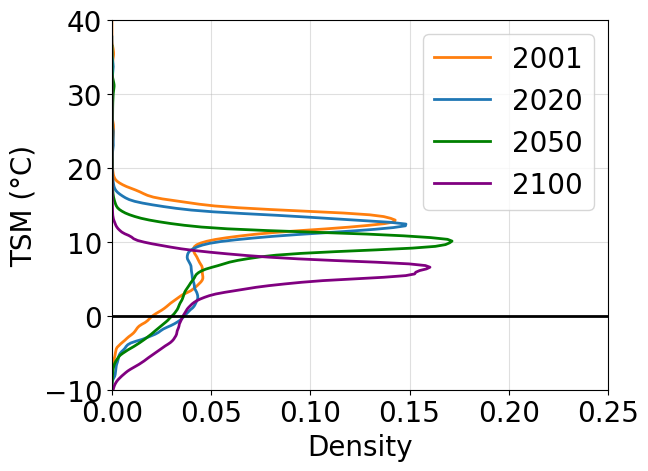

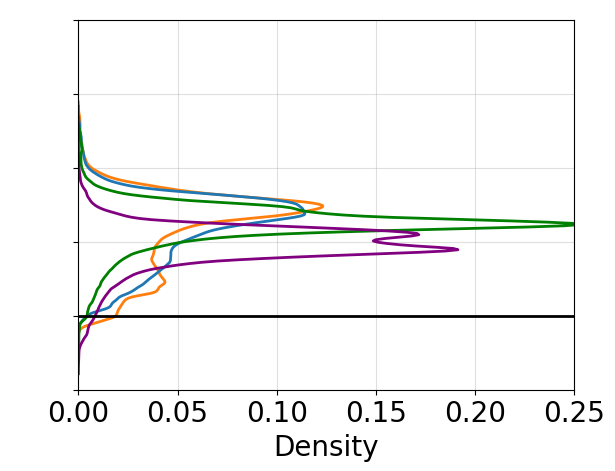

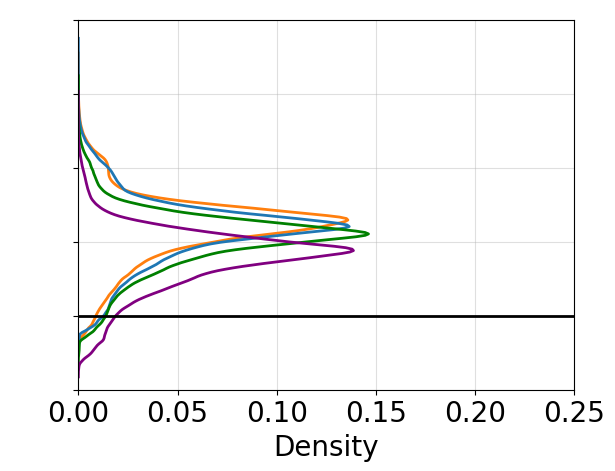

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'font.size': 20})
data_2001 = data_group[0]
data_2020 = data_group[1]
data_2050 = data_group[2]
data_2100 = data_group[3]
# data_2100ssp370 = data_group[4]
plt.rcParams.update({'font.size': 20,
                     'font.family': 'sans-serif',
                     'font.serif': 'Helvetica Neue'})

fig = plt.figure()

colors = ['tab:orange', 'tab:blue', 'green', 'purple', 'tab:pink']
linestyles = ['dashed', 'dashdot', 'dotted']
legends = ["SE Asia", "South America", "Africa"]
order = [1,2,0]
for i in range(3):
    o = order[i]
    # plt.subplot(1,3,i+1)
    plt.figure()
    sns.kdeplot(y=data_2001[o], color = colors[0], linewidth=2)
    sns.kdeplot(y=data_2020[o], color = colors[1], linewidth=2)
    sns.kdeplot(y=data_2050[o], color = colors[2], linewidth=2)
    sns.kdeplot(y=data_2100[o], color = colors[3], linewidth=2)
    # sns.kdeplot(y=data_2100ssp370[o], color = colors[4])
    plt.plot([], c=colors[0], label='2001', linewidth=2)
    plt.plot([], c=colors[1], label='2020', linewidth=2)
    plt.plot([], c=colors[2], label='2050', linewidth=2)
    plt.plot([], c=colors[3], label='2100', linewidth=2)
    # plt.plot([], c=colors[4], label='2100')
    if i == 0:
        plt.ylabel('TSM (°C)')
        plt.legend()
    else:
        plt.gca().yaxis.set_tick_params(labelcolor='none')
    # if i == 2:
        # plt.xlabel(legends[o])
    plt.ylim(-10,40)
    plt.xlim(0,0.25)
    plt.grid(alpha=0.4)
    # 
    plt.hlines(y=0,xmin=0, xmax=0.25, colors='black', linewidth=2)
